In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patches
import os

In [2]:
score_df = pd.read_csv("../data/5m2jD_grafting_74A_94R_temp07_s50_250917/extract_distance/filter_best/grafted_raw_embeddings.tsv", sep="\t")
score_df['PDB_ID'] = score_df['PDB_ID'].str.split('_').str[2:4].str.join("*")
selected_df = score_df[['PDB_ID', 'grafted_euclidean_all_raw_embeddings']]

In [3]:
def plot_pyramid_with_labels(
    df,
    pdb_col=0, value_col=1,
    percentages=[5,10,20,50,100],
    colors=None,
    figsize=(6,8),
    savepath=None,
    show_pdbs=None,       # list of PDBs to show/highlight (None => show all)
    show_only=False,      # if True show only show_pdbs
    highlight_color='black',
    highlight_linewidth=1.2,
    pyramid_width=2.0,
    pyramid_height=1.0,
    pyramid_center_x=0.0,
    pyramid_base_y=0.0,
    label_x=None,
    connector_pad=0.01,
    first_row_on_top=False,
    label_fontsize=9,      # 字体大小（points）
    max_columns=2,         # 1 or 2: 当 1 无法放下时可切到 2 列
    min_gap_factor=1.05    # 标签高度的放大系数，确保略有空隙
):
    """
    绘制分层金字塔并在右侧标注 PDB_ID，自动避免标签重叠并可分两列。
    连接线从金字塔右边缘上的“原始高度”（基于 df 顺序）画到标签位置（斜线）。
    """

    # --- 数据准备 ---
    pdbs_all = df.iloc[:, pdb_col].astype(str).values
    n = len(pdbs_all)
    if n == 0:
        raise ValueError("DataFrame is empty.")

    # show_pdbs 预处理（只保留存在的）
    if show_pdbs is not None:
        show_set = set(map(str, show_pdbs))
        present = [p for p in pdbs_all if p in show_set]
        missing = [p for p in show_set if p not in pdbs_all]
        if missing:
            print(f"Warning: these requested PDB_IDs were not found and will be ignored: {missing}")
    else:
        present = []

    # percentages 校验
    if percentages[-1] != 100:
        raise ValueError("Last element of percentages must be 100.")
    cum = np.array(percentages) / 100.0
    layer_fracs = np.diff(np.concatenate(([0.0], cum)))

    if colors is None:
        # colors = ["lightcoral", "lightsteelblue", "lightgreen", "khaki", "plum"]
        # colors = ["#B42B22",  "#830783", "#996121", "#0E8585", "#315A89"]   # Dark
        # colors = ["#FCB2AF", "#FFE2CE", "#C4D8E9", "#9BDFDF", "#BEBCDF"]  # Light
        colors = ["#D26546", "#EBBD76", "#986532", "#6EA486", "#3B5B8B"]
    if len(colors) < len(layer_fracs):
        colors = (colors * ((len(layer_fracs) // len(colors)) + 1))[:len(layer_fracs)]

    if label_x is None:
        label_x = pyramid_center_x + pyramid_width/2 + 0.18 * pyramid_width

    # --- 建图 ---
    fig, ax = plt.subplots(1,1, figsize=figsize)

    base_left = (pyramid_center_x - pyramid_width/2, pyramid_base_y)
    base_right = (pyramid_center_x + pyramid_width/2, pyramid_base_y)
    apex = (pyramid_center_x, pyramid_base_y + pyramid_height)

    def half_width_at_y(y):
        frac = (y - pyramid_base_y) / pyramid_height
        frac = np.clip(frac, 0.0, 1.0)
        return (pyramid_width / 2.0) * (1.0 - frac)

    # draw layers top -> bottom
    y_top = pyramid_base_y + pyramid_height
    for frac, col in zip(layer_fracs, colors):
        layer_h = frac * pyramid_height
        y_bottom = y_top - layer_h
        hw_top = half_width_at_y(y_top)
        hw_bottom = half_width_at_y(y_bottom)
        poly_pts = [
            (pyramid_center_x - hw_bottom, y_bottom),
            (pyramid_center_x - hw_top,    y_top),
            (pyramid_center_x + hw_top,    y_top),
            (pyramid_center_x + hw_bottom, y_bottom),
        ]
        patch = patches.Polygon(poly_pts, closed=True, facecolor=col, edgecolor="k", linewidth=0.6)
        ax.add_patch(patch)
        y_top = y_bottom
    # outline
    ax.add_patch(patches.Polygon([base_left, apex, base_right], closed=True, fill=False, edgecolor="k", linewidth=1.0))

    # --- 计算每行（每个 PDB）原始高度（中心） ---
    ys_norm = (np.arange(n) + 0.5) / n  # 0..1 bottom->top
    if first_row_on_top:
        ys_norm = 1.0 - ys_norm
    ys = pyramid_base_y + ys_norm * pyramid_height
    pdb_to_y = {p: y for p, y in zip(pdbs_all, ys)}

    # 决定要绘制哪些标签，以及哪些需要高亮
    if show_pdbs is None:
        labels_to_plot = pdbs_all.tolist()
        highlight_set = set()
    else:
        if show_only:
            labels_to_plot = present
            highlight_set = set(present)
        else:
            labels_to_plot = pdbs_all.tolist()
            highlight_set = set(present)

    # --- 估算单个标签在 data(纵)坐标系中的高度（依 label_fontsize） ---
    # 先画一次画布以获得 renderer 与 ax.bbox
    fig.canvas.draw()
    # 用一个临时文本来测量像素高度（取最长字符串的bbox来近似）
    sample_text = max(labels_to_plot, key=len) if labels_to_plot else "M"
    temp_text = ax.text(label_x, ys[0], sample_text, fontsize=label_fontsize, family='monospace', visible=False)
    renderer = fig.canvas.get_renderer()
    bbox = temp_text.get_window_extent(renderer=renderer)
    temp_text.remove()
    text_height_px = bbox.height
    axes_height_px = ax.bbox.height
    data_yrange = ax.get_ylim()[1] - ax.get_ylim()[0]
    dy_per_px = data_yrange / axes_height_px
    label_h_data = text_height_px * dy_per_px * min_gap_factor  # 加点余量
    min_gap = label_h_data

    # --- 布局：先贪心放置Y（单列），避免重叠（两次扫描） ---
    # 初始 desired positions in descending y (top -> bottom) for easier pushing down
    label_list = labels_to_plot.copy()
    # We'll operate in a column-wise manner later if needed
    desired = np.array([pdb_to_y[p] for p in label_list], dtype=float)

    # a function to perform two-pass greedy adjustment within bounds [ymin, ymax]
    def adjust_positions(desired_y, ymin, ymax, min_gap):
        # desired_y: array (len m) of desired positions (no particular order)
        # We will sort by desired_y descending, then push down if too close, then push up pass
        order = np.argsort(-desired_y)  # indices to visit from top to bottom
        y_adj = desired_y.copy()
        # first pass: top->bottom, ensure each is at most prev - min_gap
        for idx in order:
            if idx == order[0]:
                # ensure within bounds
                if y_adj[idx] > ymax:
                    y_adj[idx] = ymax
                continue
            # previous in top->bottom sequence:
            prev_idx = order[np.where(order == idx)[0][0] - 1]
            if y_adj[idx] > y_adj[prev_idx] - min_gap:
                y_adj[idx] = y_adj[prev_idx] - min_gap
        # second pass: bottom->top, ensure within bounds lower limit and push up if necessary
        order_b = order[::-1]  # bottom->top
        for idx in order_b:
            if idx == order_b[0]:
                if y_adj[idx] < ymin:
                    y_adj[idx] = ymin
                continue
            prev_idx = order_b[np.where(order_b == idx)[0][0] - 1]
            if y_adj[idx] < y_adj[prev_idx] + min_gap:
                y_adj[idx] = y_adj[prev_idx] + min_gap
        # final clamp to bounds and re-run small relaxation if clipped
        y_adj = np.clip(y_adj, ymin, ymax)
        # if some clipped and cause overlap, do another simple relaxation top->bottom
        for idx in order:
            if idx == order[0]:
                continue
            prev_idx = order[np.where(order == idx)[0][0] - 1]
            if y_adj[idx] > y_adj[prev_idx] - min_gap:
                y_adj[idx] = y_adj[prev_idx] - min_gap
        y_adj = np.clip(y_adj, ymin, ymax)
        return y_adj

    ymin = pyramid_base_y + 0.0 * pyramid_height
    ymax = pyramid_base_y + pyramid_height

    # try single-column first
    adjusted_single = adjust_positions(desired.copy(), ymin, ymax, min_gap)

    # check whether any overlaps still exist (distance < min_gap)
    def has_overlap(y_positions, min_gap):
        y_sorted = np.sort(y_positions)[::-1]
        diffs = y_sorted[:-1] - y_sorted[1:]
        return np.any(diffs < min_gap - 1e-9)

    need_two_columns = False
    if has_overlap(adjusted_single, min_gap):
        # if allowed, try splitting into two columns
        if max_columns >= 2:
            need_two_columns = True
        else:
            # try to relax by scaling min_gap down until fits (but not less than 0.7 * label_h_data)
            scale = 0.95
            adj = adjusted_single.copy()
            while has_overlap(adj, min_gap * scale) and scale > 0.7:
                adj = adjust_positions(desired.copy(), ymin, ymax, min_gap * scale)
                scale *= 0.95
            adjusted_single = adj
            if has_overlap(adjusted_single, min_gap * scale):
                # give up and keep adjusted_single (it will overlap a bit)
                pass

    if not need_two_columns:
        final_positions = adjusted_single
        columns = 1
        col_assignment = np.zeros(len(label_list), dtype=int)
    else:
        # split labels into two groups by alternating after sorting by desired (descending)
        order_desc = np.argsort(-desired)
        col_assignment = np.zeros(len(label_list), dtype=int)
        # Alternate assignment to try to balance vertical packing
        col_assignment[order_desc[0::2]] = 0
        col_assignment[order_desc[1::2]] = 1
        final_positions = np.zeros(len(label_list), dtype=float)
        # compute column bounds for label y (both columns share same ymin,ymax)
        # adjust each column separately
        for col in [0,1]:
            idxs = np.where(col_assignment == col)[0]
            if len(idxs) == 0:
                continue
            desired_col = desired[idxs]
            adj_col = adjust_positions(desired_col, ymin, ymax, min_gap)
            final_positions[idxs] = adj_col
        columns = 2

    # --- 绘制连接线与文字（连接点使用原始高度上的三角边界，线可斜） ---
    for i, pdb in enumerate(label_list):
        y_orig = pdb_to_y[pdb]
        y_label = final_positions[i]
        hw = half_width_at_y(y_orig)
        x_edge = pyramid_center_x + hw
        x_start = x_edge + np.sign(label_x - x_edge) * connector_pad * pyramid_width
        # for two columns, set label x to further right for column 1
        if columns == 1:
            x_text = label_x
        else:
            # column 0 near label_x, column1 further right
            if col_assignment[i] == 0:
                x_text = label_x
            else:
                x_text = label_x + 0.18 * pyramid_width

        is_high = (pdb in highlight_set)
        if is_high:
            lw = highlight_linewidth
            color = highlight_color
            alpha = 1.0
            ls = '-'
        else:
            lw = 0.6
            color = 'gray'
            alpha = 0.7
            ls = '--'

        # draw straight line from (x_start, y_orig) to (x_text - small offset, y_label)
        x_text_anchor = x_text - 0.01 * pyramid_width
        ax.plot([x_start, x_text_anchor], [y_orig, y_label], linewidth=lw, linestyle=ls, color=color, alpha=alpha)
        ax.text(x_text, y_label, pdb, va='center', ha='left', fontsize=label_fontsize, family='monospace',
                color=color, alpha=alpha)

    # formatting & legend (same as earlier)
    padding_left = pyramid_center_x - pyramid_width/2 - 0.2 * pyramid_width
    padding_right = label_x + 0.45 * pyramid_width
    ax.set_xlim(padding_left, padding_right)
    ax.set_ylim(pyramid_base_y - 0.02 * pyramid_height, pyramid_base_y + pyramid_height + 0.02 * pyramid_height)
    ax.axis('off')
    ax.set_aspect('equal', adjustable='box')

    cum_labels = []
    start = 0
    for p in percentages:
        cum_labels.append(f"{start}% → {p}%")
        start = p
    legend_x = pyramid_center_x - pyramid_width/2 - 0.02 * pyramid_width
    for i, lab in enumerate(cum_labels):
        y_legend = pyramid_base_y + pyramid_height - 0.06 * pyramid_height - i * 0.055 * pyramid_height
        ax.text(legend_x - 0.02 * pyramid_width, y_legend, lab, fontsize=14, va='center', ha='right',
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6))
        ax.add_patch(patches.Rectangle((legend_x, y_legend - 0.02 * pyramid_height),
                                      0.05 * pyramid_width, 0.035 * pyramid_height,
                                      facecolor=colors[i], edgecolor='k', linewidth=0.4))

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=600, bbox_inches='tight')
    plt.show()
    return fig, ax

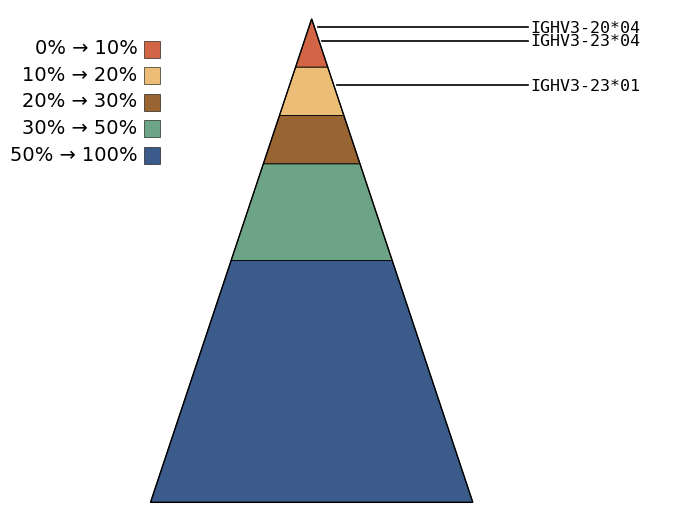

In [4]:

show_pdbs = ['IGHV3-23*04', 'IGHV3-23*01', 'IGHV3-20*04']
# show_pdbs = ['IGHV3-23*04', 'IGHV3-23*01', 'IGHV3-16*01']

fig, ax = plot_pyramid_with_labels(
        selected_df,
        pdb_col=0,
        value_col=1,
        percentages=[10,20,30,50,100],
        pyramid_width=2.0,
        pyramid_height=3.0,
        pyramid_center_x=-0.1,
        pyramid_base_y=0.0,
        figsize=(7,10),
        show_pdbs=show_pdbs,
        show_only=True,
        first_row_on_top=True,
        label_fontsize=12,
        max_columns=3,
        savepath='/home/dhuang/work/Ig-fold/nanobody_db/final_version/figures/TNF30_pyramid.png'
    )